<a href="https://colab.research.google.com/github/enriquefroes/previsao-brasileirao-2026/blob/main/notebooks/03_reta_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_previsao_brasileirao'
except ImportError:
    BASE = './analise_previsao_brasileirao'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (GRAF, TAB):
    os.makedirs(p, exist_ok=True)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150, bbox_inches='tight')
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

def exige(arquivo, notebook):
    if not os.path.exists(os.path.join(DADOS, arquivo)):
        raise FileNotFoundError(f'Rode primeiro o notebook {notebook}')

exige('forca_times.csv', '01_forca_dos_times')
p = pd.read_csv(os.path.join(DADOS, 'partidas_realizadas.csv'), parse_dates=['data'])
r = pd.read_csv(os.path.join(DADOS, 'jogos_restantes.csv'), parse_dates=['data'])
copas = pd.read_csv(os.path.join(DADOS, 'calendario_copas.csv'), parse_dates=['data'])
forca = pd.read_csv(os.path.join(DADOS, 'forca_times.csv'), index_col='time')
par = pd.read_csv(os.path.join(DADOS, 'parametros_modelo.csv'), index_col=0).iloc[:, 0]
times = sorted(forca.index)
idx = {t: i for i, t in enumerate(times)}
n = len(times)
ATK = np.log(forca.loc[times, 'ataque'].values)
DEF = np.log(forca.loc[times, 'defesa'].values)

def tabela_atual():
    pts, vit, gp, gc = (np.zeros(n) for _ in range(4))
    for _, g in p.iterrows():
        a, b, x, z = idx[g['mandante']], idx[g['visitante']], g['gols_mandante'], g['gols_visitante']
        gp[a] += x; gc[a] += z; gp[b] += z; gc[b] += x
        if x > z: pts[a] += 3; vit[a] += 1
        elif x < z: pts[b] += 3; vit[b] += 1
        else: pts[a] += 1; pts[b] += 1
    return pts, vit, gp, gc

def gols_esperados(desgaste=0.0, janela=3):
    """Gols esperados de mandante e visitante em cada jogo restante.
    desgaste: redução no ataque (e aumento nos gols sofridos) de quem tem jogo de copa a até `janela` dias."""
    H = np.array([idx[t] for t in r['mandante']]); A = np.array([idx[t] for t in r['visitante']])
    lh = np.exp(par['intercepto'] + par['mando'] + ATK[H] + DEF[A])
    la = np.exp(par['intercepto'] + ATK[A] + DEF[H])
    if desgaste:
        for k, j in r.iterrows():
            if pd.isna(j['data']):
                continue
            for lado, time in [('m', j['mandante']), ('v', j['visitante'])]:
                c = copas[copas['time'] == time]
                if ((c['data'] - j['data']).abs().dt.days <= janela).any():
                    if lado == 'm': lh[k] *= 1 - desgaste; la[k] *= 1 + desgaste
                    else: la[k] *= 1 - desgaste; lh[k] *= 1 + desgaste
    return H, A, lh, la

def simular(N=20000, desgaste=0.0, semente=42):
    rng = np.random.default_rng(semente)
    H, A, lh, la = gols_esperados(desgaste)
    gh = rng.poisson(lh, (N, len(r))); ga = rng.poisson(la, (N, len(r)))
    pts0, vit0, gp0, gc0 = tabela_atual()
    pts, vit, gp, gc = (np.tile(v, (N, 1)) for v in (pts0, vit0, gp0, gc0))
    for k in range(len(r)):
        h, a, x, z = H[k], A[k], gh[:, k], ga[:, k]
        pts[:, h] += 3 * (x > z) + (x == z); pts[:, a] += 3 * (z > x) + (x == z)
        vit[:, h] += x > z; vit[:, a] += z > x
        gp[:, h] += x; gc[:, h] += z; gp[:, a] += z; gc[:, a] += x

    chave = pts * 1e9 + vit * 1e6 + (gp - gc + 500) * 1e3 + gp + rng.random((N, n)) * 1e-3
    pos = (-chave).argsort(1).argsort(1) + 1
    return pts, pos, np.sign(gh - ga).astype(np.int8)


Mounted at /content/drive


In [2]:
exige('simulacoes.npz', '02_simulacao')
sim = np.load(os.path.join(DADOS, 'simulacoes.npz'))
pts, pos = sim['pts'], sim['pos']
pts0 = tabela_atual()[0]
jogos_feitos = pd.concat([p['mandante'], p['visitante']]).value_counts()
H, A, lh, la = gols_esperados()

def pontos_esperados(l1, l2, maxg=10):
    """Pontos esperados de um time com média l1 de gols contra um adversário com média l2."""
    from scipy.stats import poisson
    g = np.arange(maxg)
    m = np.outer(poisson.pmf(g, l1), poisson.pmf(g, l2))
    return 3 * np.tril(m, -1).sum() + np.trace(m)

linhas = []
for k, j in r.iterrows():
    linhas.append({'time': j['mandante'], 'adversario': j['visitante'], 'mando': 'casa', 'data': j['data'], 'rodada': j['rodada'], 'pontos_esp': pontos_esperados(lh[k], la[k])})
    linhas.append({'time': j['visitante'], 'adversario': j['mandante'], 'mando': 'fora', 'data': j['data'], 'rodada': j['rodada'], 'pontos_esp': pontos_esperados(la[k], lh[k])})
rest = pd.DataFrame(linhas)

reta = rest.groupby('time').agg(jogos_restantes=('pontos_esp', 'size'), pontos_esp=('pontos_esp', 'sum'))
reta['forca_adversarios'] = rest.assign(f=rest['adversario'].map(forca['forca'])).groupby('time')['f'].mean()
reta['aprov_atual'] = pts0[[idx[t] for t in reta.index]] / (3 * jogos_feitos.reindex(reta.index)) * 100
reta['aprov_previsto'] = reta['pontos_esp'] / (3 * reta['jogos_restantes']) * 100
reta = reta.sort_values('aprov_previsto', ascending=False)
reta.round(2).to_csv(os.path.join(TAB, '03_reta_final.csv'))
reta.round(1)

,jogos_restantes,pontos_esp,forca_adversarios,aprov_atual,aprov_previsto
time,,,,,
Flamengo,10,20.4,1.1,71.4,68.0
Palmeiras,10,19.7,1.1,67.9,65.6
Athletico-PR,10,16.5,1.1,58.3,55.0
Fluminense,10,16.3,1.0,57.1,54.2
Cruzeiro,10,15.3,1.1,53.6,51.0
Bragantino,10,15.1,1.0,42.9,50.3
Atlético-MG,10,14.5,1.1,51.2,48.5
Bahia,10,14.2,1.2,54.8,47.4
São Paulo,10,14.0,1.0,42.9,46.8


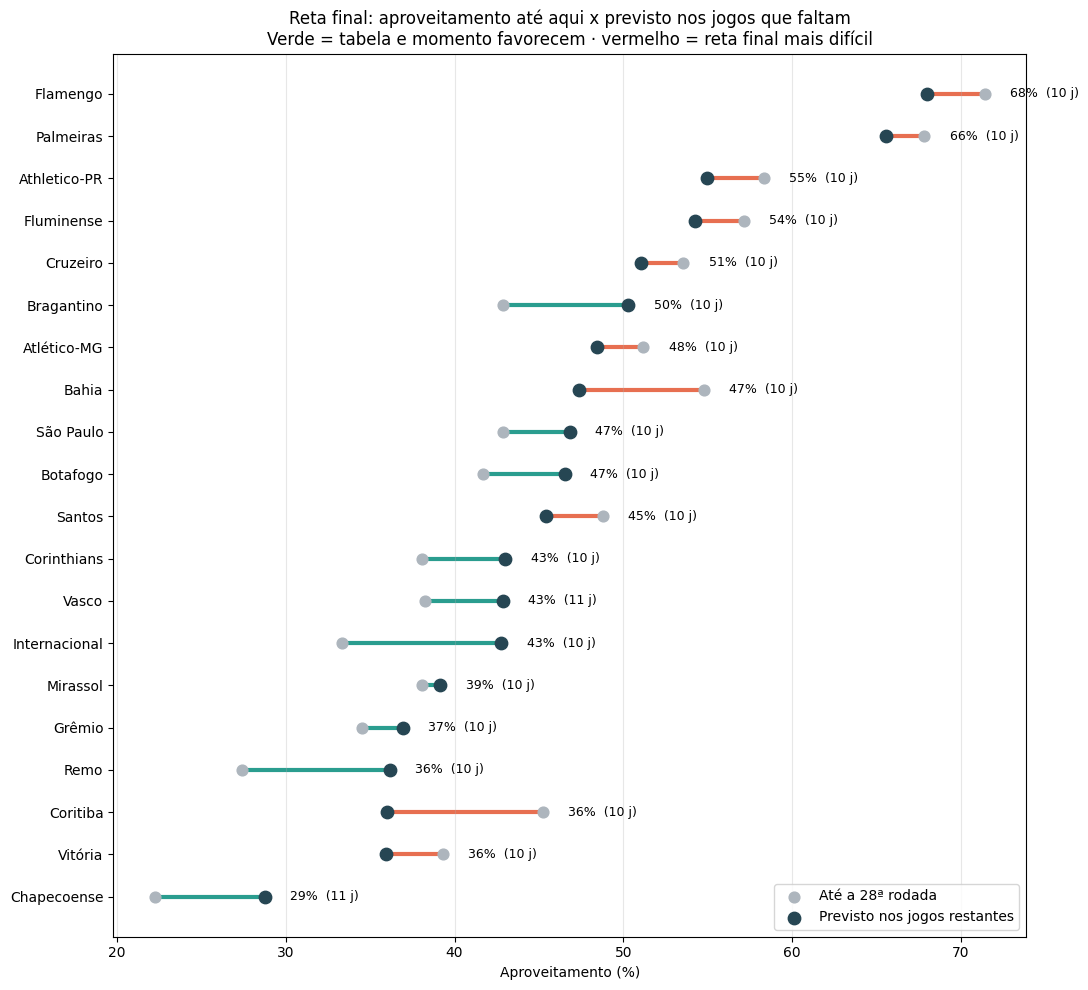

Salvo em /content/drive/MyDrive/analise_previsao_brasileirao/graficos/03a_aproveitamento_reta_final.png


In [3]:
t = reta.sort_values('aprov_previsto')
fig, ax = plt.subplots(figsize=(11, 10))
y = np.arange(len(t))
for i, (a, b) in enumerate(zip(t['aprov_atual'], t['aprov_previsto'])):
    ax.plot([a, b], [i, i], color='#2a9d8f' if b > a else '#e76f51', lw=3, zorder=1)
ax.scatter(t['aprov_atual'], y, color='#adb5bd', s=60, zorder=3, label='Até a 28ª rodada')
ax.scatter(t['aprov_previsto'], y, color='#264653', s=80, zorder=4, label='Previsto nos jogos restantes')
for i, (b, jr) in enumerate(zip(t['aprov_previsto'], t['jogos_restantes'])):
    ax.text(max(b, t['aprov_atual'].iloc[i]) + 1.5, i, f'{b:.0f}%  ({jr} j)', va='center', fontsize=9)
ax.set_yticks(y); ax.set_yticklabels(t.index)
ax.set_xlabel('Aproveitamento (%)')
ax.set_title('Reta final: aproveitamento até aqui x previsto nos jogos que faltam\nVerde = tabela e momento favorecem · vermelho = reta final mais difícil', fontsize=12)
ax.legend(loc='lower right'); ax.grid(axis='x', alpha=0.3)
salvar('03a_aproveitamento_reta_final.png')

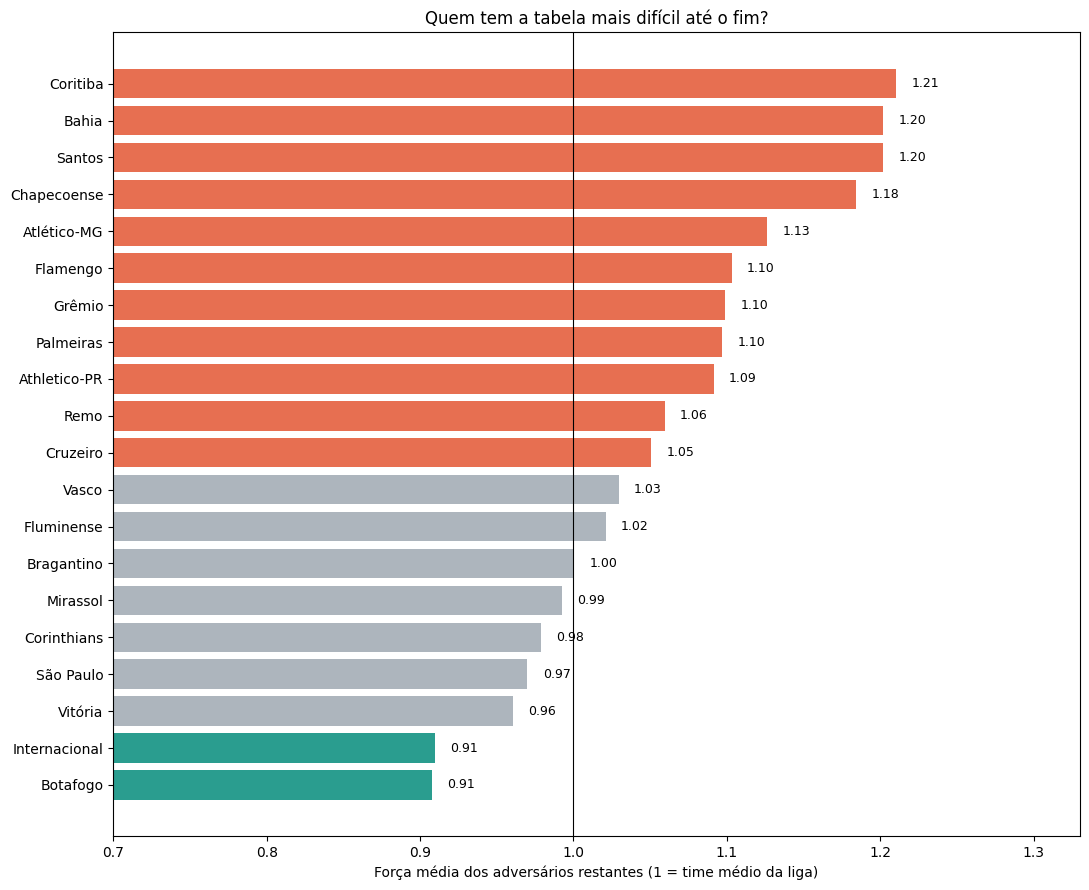

Salvo em /content/drive/MyDrive/analise_previsao_brasileirao/graficos/03b_dificuldade_tabela.png


In [4]:
t = reta.sort_values('forca_adversarios')
fig, ax = plt.subplots(figsize=(11, 9))
ax.barh(t.index, t['forca_adversarios'], color=['#e76f51' if v > 1.05 else '#2a9d8f' if v < 0.95 else '#adb5bd' for v in t['forca_adversarios']])
ax.axvline(1, color='black', lw=0.8)
for i, v in enumerate(t['forca_adversarios']):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center', fontsize=9)
ax.set_xlim(0.7, t['forca_adversarios'].max() + 0.12)
ax.set_xlabel('Força média dos adversários restantes (1 = time médio da liga)')
ax.set_title('Quem tem a tabela mais difícil até o fim?', fontsize=12)
salvar('03b_dificuldade_tabela.png')

In [5]:
linha_top6 = np.median(np.sort(pts, axis=1)[:, ::-1][:, 5])
linha_z4 = np.median(np.sort(pts, axis=1)[:, ::-1][:, 16])
print(f'Linha do top 6: cerca de {linha_top6:.0f} pontos  ·  linha do rebaixamento: o 17º termina com cerca de {linha_z4:.0f} pontos')
reta['pontos_hoje'] = pts0[[idx[t] for t in reta.index]]
for nome, linha in [('top6', linha_top6 + 1), ('escapar_z4', linha_z4 + 1)]:
    falta = linha - reta['pontos_hoje']
    reta[f'precisa_{nome}_aprov'] = (falta / (3 * reta['jogos_restantes']) * 100).clip(lower=0).round(0)
print('0 = já está acima da linha · acima de 100 = matematicamente difícil sem tropeços dos rivais')
reta[['pontos_hoje', 'jogos_restantes', 'aprov_previsto', 'precisa_top6_aprov', 'precisa_escapar_z4_aprov']].round(1)

Linha do top 6: cerca de 59 pontos  ·  linha do rebaixamento: o 17º termina com cerca de 40 pontos
0 = já está acima da linha · acima de 100 = matematicamente difícil sem tropeços dos rivais


,pontos_hoje,jogos_restantes,aprov_previsto,precisa_top6_aprov,precisa_escapar_z4_aprov
time,,,,,
Flamengo,60.0,10,68.0,0.0,0.0
Palmeiras,57.0,10,65.6,10.0,0.0
Athletico-PR,49.0,10,55.0,37.0,0.0
Fluminense,48.0,10,54.2,40.0,0.0
Cruzeiro,45.0,10,51.0,50.0,0.0
Bragantino,36.0,10,50.3,80.0,17.0
Atlético-MG,43.0,10,48.5,57.0,0.0
Bahia,46.0,10,47.4,47.0,0.0
São Paulo,36.0,10,46.8,80.0,17.0


In [6]:
colados = []
for _, j in r.dropna(subset=['data']).iterrows():
    for time in (j['mandante'], j['visitante']):
        c = copas[(copas['time'] == time) & ((copas['data'] - j['data']).abs().dt.days <= 3)]
        for _, cc in c.iterrows():
            colados.append({'time': time, 'jogo_brasileirao': f"{j['mandante']} x {j['visitante']}", 'data': j['data'].date(),
                            'copa': f"{cc['competicao']} ({cc['fase']})", 'data_copa': cc['data'].date()})
colados = pd.DataFrame(colados)
colados.to_csv(os.path.join(TAB, '03_calendario_apertado.csv'), index=False)
print(colados.groupby('time').size().sort_values(ascending=False).rename('jogos colados a copas').to_string())
colados

time
Atlético-MG    5
Vasco          4
Palmeiras      4
Grêmio         3
Fluminense     3
Flamengo       1


,time,jogo_brasileirao,data,copa,data_copa
0,Vasco,Vasco x Remo,2026-10-10,Sul-Americana (semifinal ida),2026-10-13
1,Atlético-MG,Atlético-MG x Santos,2026-10-11,Sul-Americana (semifinal ida),2026-10-14
2,Palmeiras,Palmeiras x Corinthians,2026-10-11,Libertadores (semifinal ida),2026-10-14
3,Fluminense,Flamengo x Fluminense,2026-10-11,Libertadores (semifinal ida),2026-10-14
4,Atlético-MG,Atlético-MG x Coritiba,2026-10-17,Sul-Americana (semifinal ida),2026-10-14
5,Palmeiras,Athletico-PR x Palmeiras,2026-10-17,Libertadores (semifinal ida),2026-10-14
6,Vasco,São Paulo x Vasco,2026-10-17,Sul-Americana (semifinal volta),2026-10-20
7,Fluminense,Fluminense x Santos,2026-10-18,Libertadores (semifinal volta),2026-10-21
8,Flamengo,Bahia x Flamengo,2026-10-18,Libertadores (semifinal ida),2026-10-15
9,Palmeiras,Palmeiras x Bragantino,2026-10-24,Libertadores (semifinal volta),2026-10-21
